# How one TARD value is calculated

> For a node and a topological scale, how much did the learned representation change the relationships that existed in the original attribute space?

## 1. A tiny graph

Seven nodes. We follow node **A** throughout.

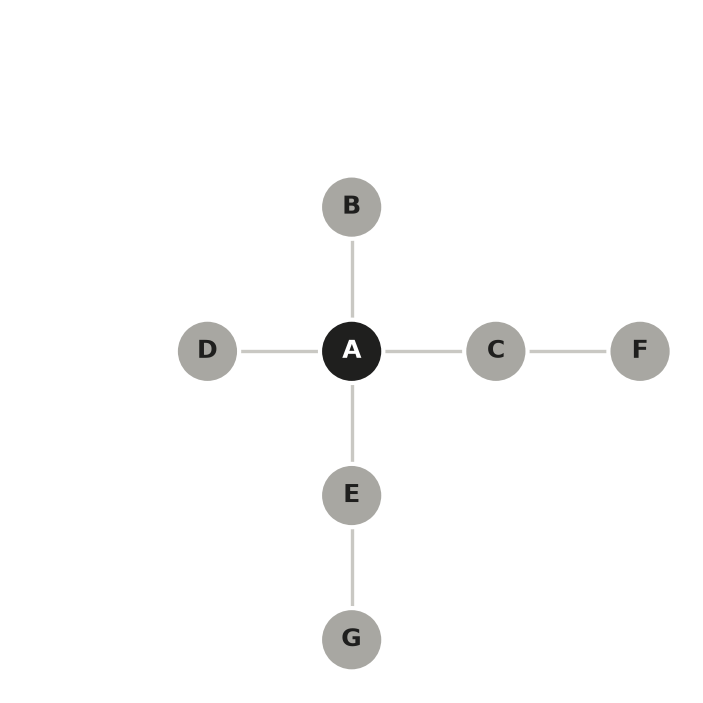

In [1]:
%config InlineBackend.figure_formats = ["retina"]

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

import tard

plt.rcParams.update(tard.visualization.STYLE)

graph = nx.Graph([("A", "B"), ("A", "C"), ("A", "D"), ("A", "E"), ("C", "F"), ("E", "G")])
LIGHT_FILLS = {"#a8a7a2", "#9ec5f4"}
positions = {
    "A": (0, 0),
    "B": (0, 1),
    "C": (1, 0),
    "D": (-1, 0),
    "E": (0, -1),
    "F": (2, 0),
    "G": (0, -2),
}


def draw_graph(node_colors, show_shells=False):
    fig, ax = plt.subplots(figsize=(3.4, 3.4), layout="constrained")
    if show_shells:
        for radius in (1, 2):
            ax.add_patch(
                plt.Circle(
                    (0, 0), radius, fill=False, color="#c9c8c3", linestyle="--", linewidth=0.8
                )
            )
            ax.text(radius * 0.74, radius * 0.74, f"{radius}-hop", color="#6b6b68", fontsize=7)
    nx.draw_networkx_edges(graph, positions, ax=ax, edge_color="#c9c8c3", width=1.2)
    nx.draw_networkx_nodes(
        graph,
        positions,
        ax=ax,
        node_color=[node_colors[node] for node in graph],
        node_size=520,
        edgecolors="white",
        linewidths=1.5,
    )
    for node in graph:
        label_color = "#1f1f1e" if node_colors[node] in LIGHT_FILLS else "white"
        nx.draw_networkx_labels(
            graph,
            positions,
            labels={node: node},
            ax=ax,
            font_size=9,
            font_color=label_color,
            font_weight="bold",
        )
    ax.set_xlim(-2.3, 2.3)
    ax.set_ylim(-2.3, 2.3)
    ax.set_aspect("equal")
    ax.set_axis_off()


draw_graph({node: "#1f1f1e" if node == "A" else "#a8a7a2" for node in graph})

## 2. Original relationships

Each node has a two-dimensional attribute vector of length 1, so it can be described by a single direction. The similarity of two nodes is the cosine of the angle between their vectors:

| angle between vectors | 0° | 60° | 90° | 120° | 180° |
|---|---|---|---|---|---|
| cosine similarity | 1 | 0.5 | 0 | −0.5 | −1 |

This is the same cosine similarity the library uses for vectors of any dimension; the angles only keep the arithmetic readable.

In [2]:
attribute_angles = pd.Series({"A": 0, "B": 60, "C": 120, "D": 60, "E": 90, "F": 180, "G": 0})
embedding_angles = pd.Series({"A": 0, "B": 60, "C": 60, "D": 90, "E": 60, "F": 180, "G": 60})


def unit_vectors(angles):
    radians = np.deg2rad(angles)
    return pd.DataFrame({"x1": np.cos(radians), "x2": np.sin(radians)}, index=angles.index).round(6)


def similarity(angles, i, j):
    return np.cos(np.deg2rad(angles[i] - angles[j])).round(3)


attributes = unit_vectors(attribute_angles)
attributes.assign(angle=attribute_angles).round(3)

,x1,x2,angle
A,1.0,0.000,0
B,0.5,0.866,60
C,-0.5,0.866,120
D,0.5,0.866,60
E,0.0,1.000,90
F,-1.0,0.000,180
G,1.0,0.000,0


The nodes exactly one hop from A are B, C, D and E. Their original similarity to A:

In [3]:
one_hop = ["B", "C", "D", "E"]
pairs = [f"A–{node}" for node in one_hop]
original = [similarity(attribute_angles, "A", node) for node in one_hop]
pd.DataFrame({"original similarity": original}, index=pairs)

,original similarity
A–B,0.5
A–C,-0.5
A–D,0.5
A–E,0.0


## 3. Learned relationships

In [4]:
embeddings = unit_vectors(embedding_angles).rename(columns={"x1": "z1", "x2": "z2"})
embeddings.assign(angle=embedding_angles).round(3)

,z1,z2,angle
A,1.0,0.000,0
B,0.5,0.866,60
C,0.5,0.866,60
D,0.0,1.000,90
E,0.5,0.866,60
F,-1.0,0.000,180
G,0.5,0.866,60


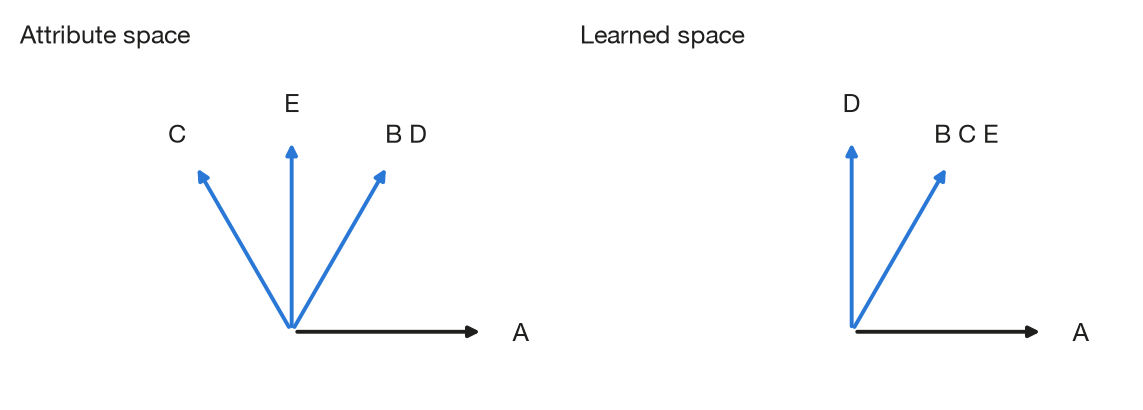

In [5]:
def draw_directions(ax, angles, title):
    for angle, nodes in angles[["A", *one_hop]].groupby(angles).groups.items():
        dx, dy = np.cos(np.deg2rad(angle)), np.sin(np.deg2rad(angle))
        color = "#1f1f1e" if "A" in nodes else "#2a78d6"
        ax.annotate(
            "",
            xy=(dx, dy),
            xytext=(0, 0),
            arrowprops={"arrowstyle": "-|>", "color": color, "linewidth": 1.4},
        )
        ax.text(1.18 * dx, 1.18 * dy, " ".join(nodes), ha="center", va="center", fontsize=9)
    ax.set_xlim(-1.4, 1.4)
    ax.set_ylim(-0.3, 1.4)
    ax.set_aspect("equal")
    ax.set_axis_off()
    ax.set_title(title, loc="left")


fig, (left, right) = plt.subplots(1, 2, figsize=(5.6, 2.2), layout="constrained")
draw_directions(left, attribute_angles, "Attribute space")
draw_directions(right, embedding_angles, "Learned space")

In the learned space B, C and E point in the same direction. For every pair we now compare the two similarities:

- **absolute change** $|r_X - r_Z|$: how much the relationship changed
- **signed change** $r_Z - r_X$: in which direction it changed. Positive means the pair became more similar, negative means less similar, zero means preserved.

In [6]:
learned = [similarity(embedding_angles, "A", node) for node in one_hop]
changes = pd.DataFrame({"original": original, "learned": learned}, index=pairs)
changes["absolute change"] = (changes["original"] - changes["learned"]).abs()
changes["signed change"] = changes["learned"] - changes["original"]
changes

,original,learned,absolute change,signed change
A–B,0.5,0.5,0.0,0.0
A–C,-0.5,0.5,1.0,1.0
A–D,0.5,0.0,0.5,-0.5
A–E,0.0,0.5,0.5,0.5


## 4. $D_{A,1}$ by hand

$$
D_{A,1} = \frac{1}{|N_1(A)|} \sum_{j \in N_1(A)} \left| r_X(A,j) - r_Z(A,j) \right|
= \frac{0 + 1 + 0.5 + 0.5}{4} = 0.5
$$

$$
S_{A,1} = \frac{1}{|N_1(A)|} \sum_{j \in N_1(A)} \left( r_Z(A,j) - r_X(A,j) \right)
= \frac{0 + 1 - 0.5 + 0.5}{4} = 0.25
$$

Both are plain averages over the rows of the table above:

In [7]:
changes[["absolute change", "signed change"]].mean()

absolute change    0.50
signed change      0.25
dtype: float64

## 5. Adding topological scale

The same calculation runs over every distance separately:

- $D_{A,1}$: nodes exactly one hop from A (B, C, D, E)
- $D_{A,2}$: nodes exactly two hops from A (F, G)

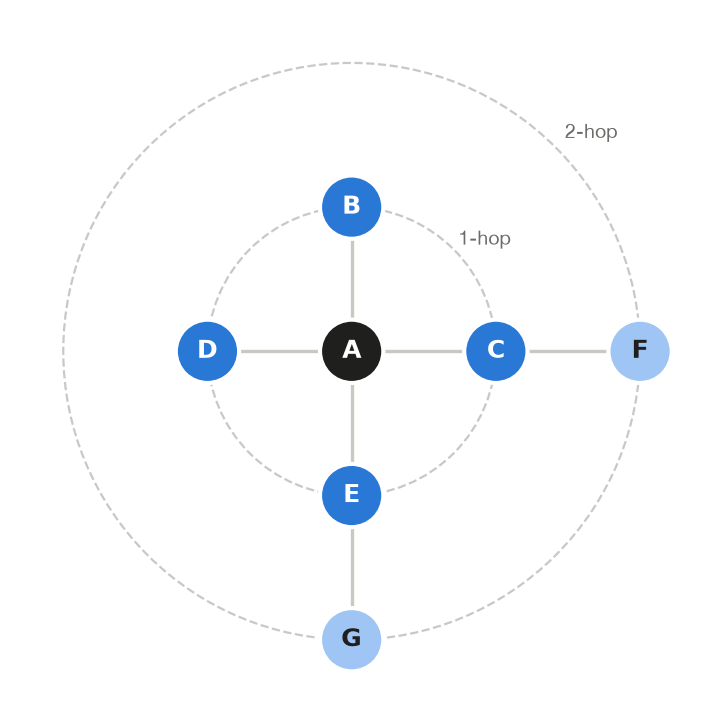

In [8]:
shell_colors = {
    "A": "#1f1f1e",
    "B": "#2a78d6",
    "C": "#2a78d6",
    "D": "#2a78d6",
    "E": "#2a78d6",
    "F": "#9ec5f4",
    "G": "#9ec5f4",
}
draw_graph(shell_colors, show_shells=True)

In [9]:
two_hop = ["F", "G"]
two_hop_changes = pd.DataFrame(
    {
        "original": [similarity(attribute_angles, "A", node) for node in two_hop],
        "learned": [similarity(embedding_angles, "A", node) for node in two_hop],
    },
    index=[f"A–{node}" for node in two_hop],
)
two_hop_changes["absolute change"] = (
    two_hop_changes["original"] - two_hop_changes["learned"]
).abs()
two_hop_changes["signed change"] = two_hop_changes["learned"] - two_hop_changes["original"]
two_hop_changes

,original,learned,absolute change,signed change
A–F,-1.0,-1.0,0.0,0.0
A–G,1.0,0.5,0.5,-0.5


$$
D_{A,2} = \frac{0 + 0.5}{2} = 0.25 \qquad S_{A,2} = \frac{0 - 0.5}{2} = -0.25
$$

At one hop A's neighbours became more similar on average; at two hops they became less similar.

## 6. From one cell to the matrix

Each cell is the same calculation, repeated for one node and one topological scale. So far we have filled one row:

In [10]:
pd.DataFrame(
    {"1-hop": [0.5, "…", "…"], "2-hop": [0.25, "…", "…"]},
    index=["A", "B", "…"],
)

,1-hop,2-hop
A,0.5,0.25
B,…,…
…,…,…


The library fills every cell:

In [11]:
result = tard.compute(
    graph=graph,
    attributes=attributes,
    embeddings=embeddings,
    max_hops=2,
)
result.distortion.round(3)

,1-hop,2-hop
A,0.50,0.250
B,0.00,0.256
C,1.00,0.333
D,0.50,0.167
E,0.75,0.089
F,1.00,0.000
G,1.00,0.500


In [12]:
result.signed_change.round(3)

,1-hop,2-hop
A,0.25,-0.250
B,0.00,0.167
C,0.00,0.333
D,-0.50,0.077
E,0.75,0.089
F,-1.00,0.000
G,1.00,-0.500


The row for A matches the hand calculation:

In [13]:
pd.DataFrame(
    {
        "by hand": [0.5, 0.25, 0.25, -0.25],
        "tard": [*result.distortion.loc["A"], *result.signed_change.loc["A"]],
    },
    index=["D_A,1", "D_A,2", "S_A,1", "S_A,2"],
).round(3)

,by hand,tard
"D_A,1",0.50,0.50
"D_A,2",0.25,0.25
"S_A,1",0.25,0.25
"S_A,2",-0.25,-0.25


## 7. The visualization

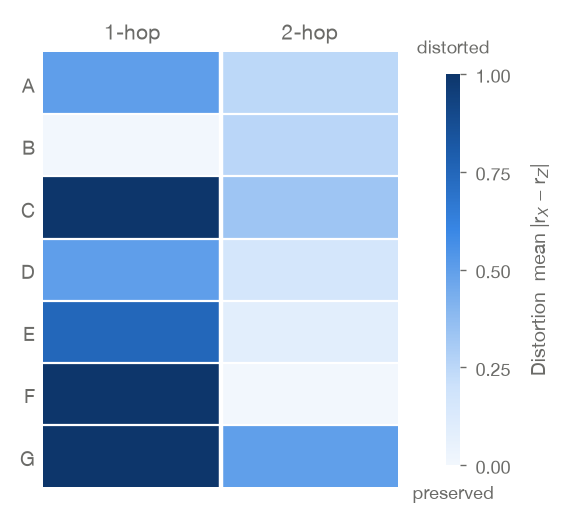

In [14]:
fig, ax = tard.plot_distortion_map(result)

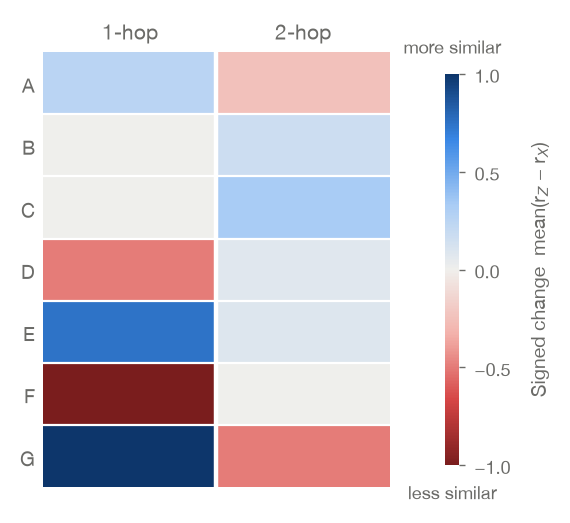

In [15]:
fig, ax = tard.plot_signed_map(result)

The visualization is simply the collection of all local node × scale calculations.